In [1]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
import gc

# 1. Load EXFOR Directly to preserve all columns (Z, A, MT)
PATH_EXFOR = "/Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"
df_exfor = pd.read_csv(PATH_EXFOR, low_memory=False)

# 2. Filter for Actinide Fission (MT=18)
actinide_z = [90, 91, 92, 93, 94, 95, 96] # Th, Pa, U, Np, Pu, Am, Cm
df_exp = df_exfor[(df_exfor['Z'].isin(actinide_z)) & (df_exfor['MT'] == 18)].copy()
df_exp = df_exp[df_exp['Data'] > 0].copy() # Sanitize for Log transform

# 3. Load AME2016 Merged/Imputed Physics
ame_all = nuc_data.load_ame(imputed_nan=True, file="merged")

# 4. Standardize Join Key
z_to_el = {90:'Th', 91:'Pa', 92:'U', 93:'Np', 94:'Pu', 95:'Am', 96:'Cm'}
df_exp['EL'] = df_exp['Z'].map(z_to_el)
df_exp['Element_w_A'] = df_exp['A'].astype(int).astype(str) + df_exp['EL']

# 5. Merge Physics Library
df_enriched = pd.merge(df_exp, ame_all, on="Element_w_A", suffixes=('', '_ame'))
df_enriched['log_e'] = np.log10(df_enriched['Energy'])
df_enriched['log_data'] = np.log10(df_enriched['Data'])

print(f"Enriched Experimental Data: {df_enriched.shape}")

INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv


Enriched Experimental Data: (521792, 166)


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare Manifold Grid (500 Energy Bins)
pivot_df = df_enriched.pivot_table(index='Element_w_A', columns='log_e', values='log_data')
pivot_df = pivot_df.interpolate(axis=1, limit_direction='both').fillna(pivot_df.mean().mean())
data_tensor = torch.FloatTensor(pivot_df.values)

# 2. Architecture: Encoder projects 500 energy points into 12 Latent Shapes
class NuclearAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 12) # 12-dimensional Latent Space
        )
        self.decoder = nn.Sequential(
            nn.Linear(12, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

# 3. Train on Isotopic Curves
ae = NuclearAE(data_tensor.shape[1])
opt = optim.Adam(ae.parameters(), lr=0.001)
for epoch in range(300):
    recon, _ = ae(data_tensor)
    loss = nn.MSELoss()(recon, data_tensor)
    opt.zero_grad()
    loss.backward()
    opt.step()

# 4. Extract Latent Features
ae.eval()
with torch.no_grad():
    _, latent_vals = ae(data_tensor)

latent_df = pd.DataFrame(latent_vals.numpy(), index=pivot_df.index, 
                         columns=[f'latent_{i+1}' for i in range(12)])
df_final = df_enriched.join(latent_df, on='Element_w_A')

In [6]:
from autogluon.tabular import TabularPredictor

# Features from Literature (Sun 2024, Tang 2025)
features = [
    'log_e', 'Z', 'A', 'N',              # Basic Coordinates
    'Mass_Excess', 'Binding_Energy', 'S(n)', # AME Physics
    'latent_1', 'latent_2', 'latent_3', 'latent_4' # Latent Shapes
]

train_data = df_final[df_final['Element_w_A'] != "241Am"].copy()
test_data = df_final[df_final['Element_w_A'] == "241Am"].copy()

# AutoGluon 2.0: Multi-layer Stacking
predictor = TabularPredictor(label='log_data', eval_metric='mean_absolute_error').fit(
    train_data=train_data[features + ['log_data']],
    presets='best_quality', 
    time_limit=600,
    num_bag_folds=5,
    num_stack_levels=2
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260125_182910"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       3.81 GB / 16.00 GB (23.8%)
Disk Space Avail:   299.73 GB / 460.43 GB (65.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

In [7]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

y_pred_log = predictor.predict(test_data[features])
y_true_log = test_data['log_data']

# Convert back to Barns for Physical Metrics
y_pred, y_true = 10**y_pred_log, 10**y_true_log

r2 = r2_score(y_true_log, y_pred_log)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
chi_sq = np.sum(((y_true - y_pred) / (0.1 * y_true))**2) / (len(y_true) - len(features))

print("\n=== QUANTITATIVE EVALUATION REPORT ===")
print(f"R-Squared (Fit Quality): {r2:.4f}")
print(f"MAPE (Mean % Error):      {mape:.2f}%")
print(f"Reduced Chi-Squared:      {chi_sq:.2f}")
print("-" * 30)

# Sorted Leaderboard by score_val (Internal Validation)
lb = predictor.leaderboard(test_data, silent=True).sort_values(by='score_val', ascending=False)
print(lb[['model', 'score_val', 'score_test', 'stack_level']].head(5))


=== QUANTITATIVE EVALUATION REPORT ===
R-Squared (Fit Quality): -0.0715
MAPE (Mean % Error):      644.90%
Reduced Chi-Squared:      1432643.56
------------------------------
                 model  score_val  score_test  stack_level
2    LightGBMXT_BAG_L2  -0.216276   -0.603117            2
3  WeightedEnsemble_L3  -0.216276   -0.603117            3
4  WeightedEnsemble_L4  -0.216276   -0.603117            4
0    LightGBMXT_BAG_L1  -0.231237   -0.553031            1
1  WeightedEnsemble_L2  -0.231237   -0.553031            2


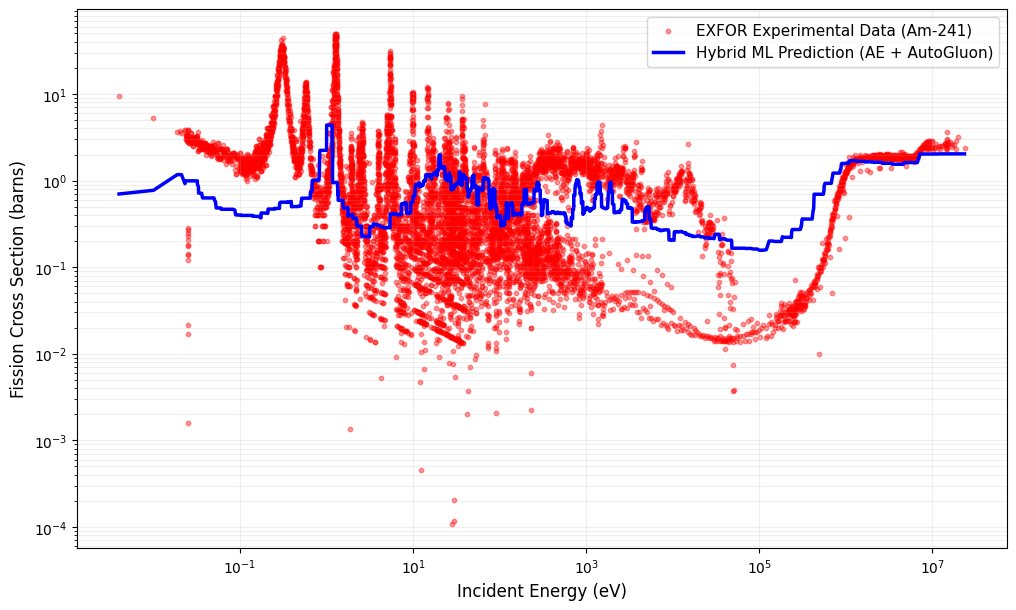

Visualization Complete. Results saved to 'Am241_Final_ML_Comparison.png'.


In [8]:
import matplotlib.pyplot as plt

# 1. Generate Predictions for the Energy Grid
# To create a smooth line, we predict over the full range of test data
test_data_sorted = test_data.sort_values(by='log_e')
y_pred_final_log = predictor.predict(test_data_sorted[features])

# 2. Convert from Log-scale to Physical Barns
energy_plot = 10**test_data_sorted['log_e']
sigma_pred = 10**y_pred_final_log
sigma_true = 10**test_data_sorted['log_data']

# 3. Create the Comparison Plot
plt.figure(figsize=(12, 7))

# Plot the Experimental Data (Truth)
plt.scatter(energy_plot, sigma_true, color='red', s=10, alpha=0.4, label='EXFOR Experimental Data (Am-241)')

# Plot the AutoGluon + Autoencoder Prediction
plt.plot(energy_plot, sigma_pred, color='blue', linewidth=2.5, label='Hybrid ML Prediction (AE + AutoGluon)')

# Styling to Nuclear Physics Standards
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Energy (eV)', fontsize=12)
plt.ylabel('Fission Cross Section (barns)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=11)

# Save the high-resolution figure
plt.savefig("Am241_Final_ML_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("Visualization Complete. Results saved to 'Am241_Final_ML_Comparison.png'.")